In [1]:
# ============================================================
# Import Required Libraries
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import os
import json
import joblib
import numpy as np
import pandas as pd

import plotly.express as px
import plotly.graph_objects as go

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# ============================================================
# Define Project Paths
# ============================================================

DATA_DIR = "../data"
PROCESSED_DATA_DIR = "../data/processed"
MODEL_DIR = "../models"
REPORT_DIR = "../reports"

os.makedirs(REPORT_DIR, exist_ok=True)

CLEAN_DATA_PATH = os.path.join(
    PROCESSED_DATA_DIR,
    "cleaned_advertising.csv"
)

FINAL_MODEL_PATH = os.path.join(
    MODEL_DIR,
    "final_model.pkl"
)

FINAL_METADATA_PATH = os.path.join(
    MODEL_DIR,
    "final_model_metadata.pkl"
)

FINAL_METADATA_JSON_PATH = os.path.join(
    REPORT_DIR,
    "final_model_metadata.json"
)

FEATURE_INTERPRETATION_PATH = os.path.join(
    REPORT_DIR,
    "feature_importance.csv"
)

FINAL_PREDICTIONS_PATH = os.path.join(
    REPORT_DIR,
    "final_model_predictions.csv"
)

print("Project paths configured successfully.")

Project paths configured successfully.


In [3]:
# ============================================================
# Verify Required Input Files
# ============================================================

required_files = {
    "Cleaned Dataset": CLEAN_DATA_PATH,
    "Final Model": FINAL_MODEL_PATH,
    "Final Model Metadata": FINAL_METADATA_PATH
}

file_status = pd.DataFrame({
    "Required File": required_files.keys(),
    "Path": required_files.values(),
    "Available": [
        os.path.exists(path)
        for path in required_files.values()
    ]
})

display(file_status)

,Required File,Path,Available
0,Cleaned Dataset,../data/processed\cleaned_advertising.csv,True
1,Final Model,../models\final_model.pkl,True
2,Final Model Metadata,../models\final_model_metadata.pkl,True


In [4]:
# Stop execution if an essential file is missing.

missing_required_files = [
    name
    for name, path in required_files.items()
    if not os.path.exists(path)
]

if missing_required_files:
    raise FileNotFoundError(
        "The following required files are missing: "
        f"{missing_required_files}. "
        "Run the previous notebooks before continuing."
    )

print("All required files are available.")

All required files are available.


In [5]:
# ============================================================
# Load Cleaned Advertising Dataset
# ============================================================

df = pd.read_csv(
    CLEAN_DATA_PATH
)

print("Cleaned dataset loaded successfully.")
display(df.head())

Cleaned dataset loaded successfully.


,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


In [6]:
# ============================================================
# Load Final Model and Metadata
# ============================================================

final_model = joblib.load(
    FINAL_MODEL_PATH
)

final_model_metadata = joblib.load(
    FINAL_METADATA_PATH
)

print("Final model and metadata loaded successfully.")

Final model and metadata loaded successfully.


In [7]:
display(
    pd.DataFrame({
        "Metadata Field": final_model_metadata.keys(),
        "Value": [
            str(value)
            for value in final_model_metadata.values()
        ]
    })
)

,Metadata Field,Value
0,project_name,AdIntel
1,model_name,Random Forest
2,feature_columns,"['TV', 'Radio', 'Newspaper']"
3,target_column,Sales
4,selection_metric,Five-fold CV RMSE
5,cv_mean_rmse,1.3015404052250497
6,cv_mean_r2,0.932767936098333
7,test_r2,0.952844707348761
8,test_mae,0.9214009920634915
9,test_rmse,1.2071248542488062


In [8]:
# ============================================================
# Extract Model Configuration
# ============================================================

project_name = final_model_metadata.get(
    "project_name",
    "AdIntel"
)

final_model_name = final_model_metadata.get(
    "model_name",
    type(final_model).__name__
)

feature_columns = final_model_metadata.get(
    "feature_columns",
    [
        "TV",
        "Radio",
        "Newspaper"
    ]
)

target_column = final_model_metadata.get(
    "target_column",
    "Sales"
)

cv_mean_rmse = final_model_metadata.get(
    "cv_mean_rmse",
    np.nan
)

test_r2 = final_model_metadata.get(
    "test_r2",
    np.nan
)

test_mae = final_model_metadata.get(
    "test_mae",
    np.nan
)

test_rmse = final_model_metadata.get(
    "test_rmse",
    np.nan
)

test_mape = final_model_metadata.get(
    "test_mape_percent",
    np.nan
)

print("Project            :", project_name)
print("Final Model        :", final_model_name)
print("Feature Columns    :", feature_columns)
print("Target Column      :", target_column)
print("Cross-val RMSE     :", round(cv_mean_rmse, 4))
print("Test R²            :", round(test_r2, 4))
print("Test MAE           :", round(test_mae, 4))
print("Test RMSE          :", round(test_rmse, 4))
print("Test MAPE (%)      :", round(test_mape, 2))


Project            : AdIntel
Final Model        : Random Forest
Feature Columns    : ['TV', 'Radio', 'Newspaper']
Target Column      : Sales
Cross-val RMSE     : 1.3015
Test R²            : 0.9528
Test MAE           : 0.9214
Test RMSE          : 1.2071
Test MAPE (%)      : 7.66


In [9]:
# ============================================================
# Validate Dataset Structure
# ============================================================

required_columns = (
    feature_columns
    + [target_column]
)

missing_columns = [
    column
    for column in required_columns
    if column not in df.columns
]

if missing_columns:
    raise ValueError(
        "The cleaned dataset is missing required columns: "
        f"{missing_columns}"
    )

if df[required_columns].isnull().any().any():
    raise ValueError(
        "Missing values were found in required columns."
    )

if not all(
    np.issubdtype(
        df[column].dtype,
        np.number
    )
    for column in required_columns
):
    raise TypeError(
        "All model features and the target must be numeric."
    )

print("Dataset structure validated successfully.")

Dataset structure validated successfully.


In [10]:
# ============================================================
# Validate End-to-End Prediction Workflow
# ============================================================

sample_features = df[
    feature_columns
].head(5).copy()

sample_predictions = final_model.predict(
    sample_features
)

prediction_validation = sample_features.copy()

prediction_validation[
    "Predicted Sales"
] = sample_predictions

prediction_validation[
    "Actual Sales"
] = df[
    target_column
].head(5).values

display(
    prediction_validation.style.format({
        "TV": "{:.2f}",
        "Radio": "{:.2f}",
        "Newspaper": "{:.2f}",
        "Predicted Sales": "{:.2f}",
        "Actual Sales": "{:.2f}"
    })
)

,TV,Radio,Newspaper,Predicted Sales,Actual Sales
0,230.10,37.80,69.20,21.98,22.10
1,44.50,39.30,45.10,10.65,10.40
2,17.20,45.90,69.30,10.47,12.00
3,151.50,41.30,58.50,16.58,16.50
4,180.80,10.80,58.40,17.81,17.90


In [11]:
# ============================================================
# Business-Level KPI Summary
# ============================================================

business_kpis = pd.DataFrame({
    "KPI": [
        "Total Observations",
        "Average Sales",
        "Median Sales",
        "Minimum Sales",
        "Maximum Sales",
        "Average TV Budget",
        "Average Radio Budget",
        "Average Newspaper Budget",
        "Total TV Budget",
        "Total Radio Budget",
        "Total Newspaper Budget"
    ],
    "Value": [
        len(df),
        df[target_column].mean(),
        df[target_column].median(),
        df[target_column].min(),
        df[target_column].max(),
        df["TV"].mean(),
        df["Radio"].mean(),
        df["Newspaper"].mean(),
        df["TV"].sum(),
        df["Radio"].sum(),
        df["Newspaper"].sum()
    ]
})

display(
    business_kpis.style.format({
        "Value": "{:,.2f}"
    })
)

,KPI,Value
0,Total Observations,200.00
1,Average Sales,15.13
2,Median Sales,16.00
3,Minimum Sales,1.60
4,Maximum Sales,27.00
5,Average TV Budget,147.04
6,Average Radio Budget,23.26
7,Average Newspaper Budget,30.55
8,Total TV Budget,"29,408.50"
9,Total Radio Budget,"4,652.80"


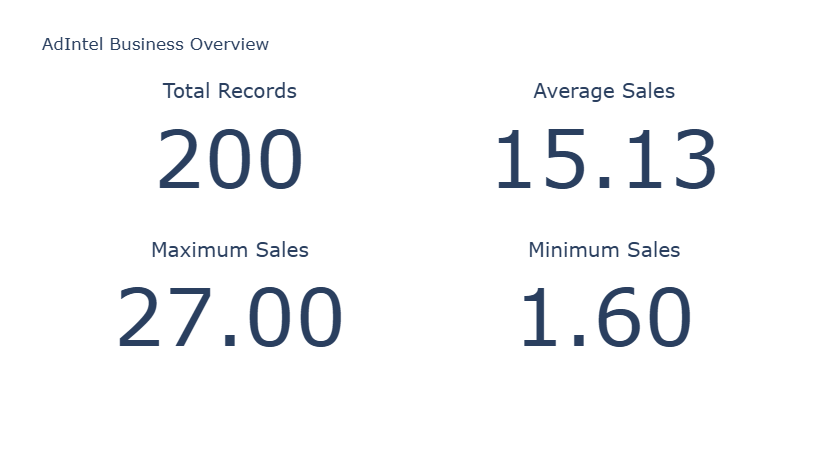

In [12]:
# ============================================================
# KPI Cards Using Plotly
# ============================================================

kpi_fig = go.Figure()

kpi_fig.add_trace(
    go.Indicator(
        mode="number",
        value=len(df),
        title={
            "text": "Total Records"
        },
        domain={
            "row": 0,
            "column": 0
        }
    )
)

kpi_fig.add_trace(
    go.Indicator(
        mode="number",
        value=df[target_column].mean(),
        number={
            "valueformat": ".2f"
        },
        title={
            "text": "Average Sales"
        },
        domain={
            "row": 0,
            "column": 1
        }
    )
)

kpi_fig.add_trace(
    go.Indicator(
        mode="number",
        value=df[target_column].max(),
        number={
            "valueformat": ".2f"
        },
        title={
            "text": "Maximum Sales"
        },
        domain={
            "row": 1,
            "column": 0
        }
    )
)

kpi_fig.add_trace(
    go.Indicator(
        mode="number",
        value=df[target_column].min(),
        number={
            "valueformat": ".2f"
        },
        title={
            "text": "Minimum Sales"
        },
        domain={
            "row": 1,
            "column": 1
        }
    )
)

kpi_fig.update_layout(
    grid={
        "rows": 2,
        "columns": 2,
        "pattern": "independent"
    },
    height=450,
    title="AdIntel Business Overview"
)

kpi_fig.show()

In [13]:
# ============================================================
# Advertising Channel Summary
# ============================================================

channel_summary = pd.DataFrame({
    "Channel": [
        "TV",
        "Radio",
        "Newspaper"
    ],
    "Average Budget": [
        df["TV"].mean(),
        df["Radio"].mean(),
        df["Newspaper"].mean()
    ],
    "Median Budget": [
        df["TV"].median(),
        df["Radio"].median(),
        df["Newspaper"].median()
    ],
    "Minimum Budget": [
        df["TV"].min(),
        df["Radio"].min(),
        df["Newspaper"].min()
    ],
    "Maximum Budget": [
        df["TV"].max(),
        df["Radio"].max(),
        df["Newspaper"].max()
    ],
    "Total Budget": [
        df["TV"].sum(),
        df["Radio"].sum(),
        df["Newspaper"].sum()
    ]
})

display(
    channel_summary.style.format({
        "Average Budget": "{:.2f}",
        "Median Budget": "{:.2f}",
        "Minimum Budget": "{:.2f}",
        "Maximum Budget": "{:.2f}",
        "Total Budget": "{:,.2f}"
    })
)

,Channel,Average Budget,Median Budget,Minimum Budget,Maximum Budget,Total Budget
0,TV,147.04,149.75,0.70,296.40,"29,408.50"
1,Radio,23.26,22.90,0.00,49.60,"4,652.80"
2,Newspaper,30.55,25.75,0.30,114.00,"6,110.80"


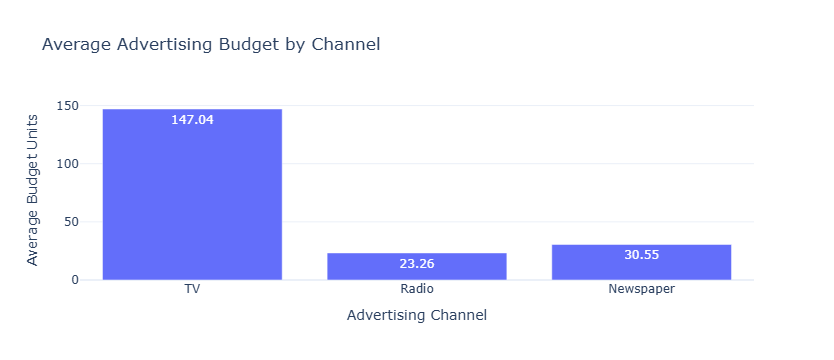

In [14]:
# ============================================================
# Average Advertising Budget by Channel
# ============================================================

fig = px.bar(
    channel_summary,
    x="Channel",
    y="Average Budget",
    text_auto=".2f",
    title="Average Advertising Budget by Channel",
    template="plotly_white"
)

fig.update_layout(
    xaxis_title="Advertising Channel",
    yaxis_title="Average Budget Units"
)

fig.show()

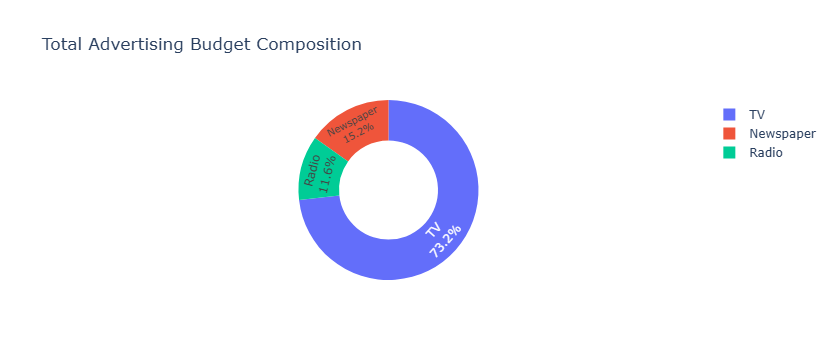

In [15]:
# ============================================================
# Total Advertising Budget Composition
# ============================================================

fig = px.pie(
    channel_summary,
    names="Channel",
    values="Total Budget",
    hole=0.55,
    title="Total Advertising Budget Composition",
    template="plotly_white"
)

fig.update_traces(
    textposition="inside",
    textinfo="label+percent"
)

fig.show()

In [16]:
# ============================================================
# Correlation of Advertising Channels with Sales
# ============================================================

channel_correlations = (
    df[
        feature_columns
        + [target_column]
    ]
    .corr(numeric_only=True)[target_column]
    .drop(target_column)
    .sort_values(ascending=False)
    .reset_index()
)

channel_correlations.columns = [
    "Channel",
    "Correlation with Sales"
]

display(
    channel_correlations.style.format({
        "Correlation with Sales": "{:.4f}"
    })
)

,Channel,Correlation with Sales
0,TV,0.9012
1,Radio,0.3496
2,Newspaper,0.1580


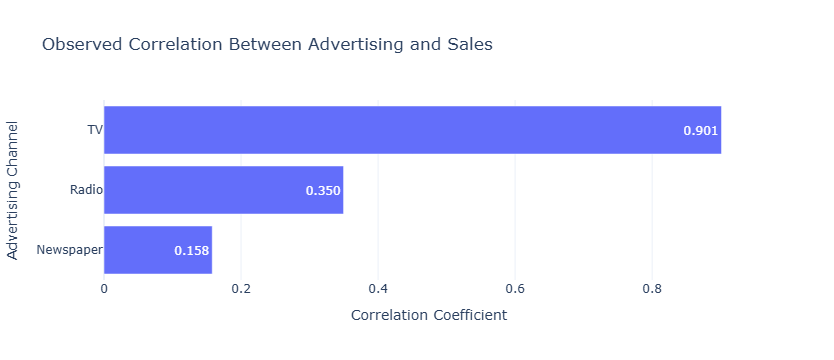

In [17]:
# ============================================================
# Correlation Bar Chart
# ============================================================

fig = px.bar(
    channel_correlations,
    x="Correlation with Sales",
    y="Channel",
    orientation="h",
    text_auto=".3f",
    title="Observed Correlation Between Advertising and Sales",
    template="plotly_white"
)

fig.update_layout(
    xaxis_title="Correlation Coefficient",
    yaxis_title="Advertising Channel",
    yaxis={
        "categoryorder": "total ascending"
    }
)

fig.show()

In [18]:
# ============================================================
# Load Saved Feature Interpretation
# ============================================================

saved_feature_interpretation = None

if os.path.exists(
    FEATURE_INTERPRETATION_PATH
):
    saved_feature_interpretation = pd.read_csv(
        FEATURE_INTERPRETATION_PATH
    )

    print(
        "Saved feature interpretation loaded successfully."
    )

    display(saved_feature_interpretation)

else:
    print(
        "No saved feature interpretation file was found."
    )

Saved feature interpretation loaded successfully.


,Feature,Importance
0,TV,0.845322
1,Radio,0.136768
2,Newspaper,0.017909


In [19]:
# ============================================================
# Generate Feature Interpretation if Needed
# ============================================================

from sklearn.pipeline import Pipeline

if saved_feature_interpretation is None:

    if isinstance(
        final_model,
        Pipeline
    ):
        underlying_model = final_model.named_steps[
            "model"
        ]
    else:
        underlying_model = final_model

    if hasattr(
        underlying_model,
        "feature_importances_"
    ):
        saved_feature_interpretation = pd.DataFrame({
            "Feature": feature_columns,
            "Importance": (
                underlying_model
                .feature_importances_
            )
        })

    elif hasattr(
        underlying_model,
        "coef_"
    ):
        saved_feature_interpretation = pd.DataFrame({
            "Feature": feature_columns,
            "Coefficient": np.ravel(
                underlying_model.coef_
            )
        })

    else:
        print(
            "The final model does not provide direct "
            "feature importance or coefficients."
        )

In [20]:
# ============================================================
# Standardize Feature Interpretation
# ============================================================

feature_strength_df = None
interpretation_source = None

if saved_feature_interpretation is not None:

    saved_feature_interpretation = (
        saved_feature_interpretation.copy()
    )

    if "Importance" in (
        saved_feature_interpretation.columns
    ):
        feature_strength_df = (
            saved_feature_interpretation[
                [
                    "Feature",
                    "Importance"
                ]
            ]
            .rename(
                columns={
                    "Importance": "Model Strength"
                }
            )
        )

        interpretation_source = (
            "Tree-Based Feature Importance"
        )

    elif "Coefficient" in (
        saved_feature_interpretation.columns
    ):
        feature_strength_df = (
            saved_feature_interpretation[
                [
                    "Feature",
                    "Coefficient"
                ]
            ]
            .copy()
        )

        feature_strength_df[
            "Model Strength"
        ] = feature_strength_df[
            "Coefficient"
        ].abs()

        interpretation_source = (
            "Absolute Linear-Model Coefficient"
        )

    feature_strength_df = (
        feature_strength_df
        .sort_values(
            by="Model Strength",
            ascending=False
        )
        .reset_index(drop=True)
    )

    display(
        feature_strength_df.style.format({
            "Model Strength": "{:.4f}",
            "Coefficient": "{:.4f}"
        })
    )

,Feature,Model Strength
0,TV,0.8453
1,Radio,0.1368
2,Newspaper,0.0179


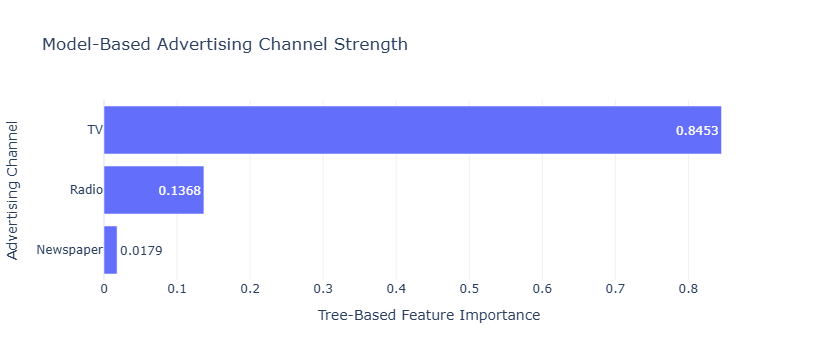

In [21]:
# ============================================================
# Plot Model-Based Feature Strength
# ============================================================

if feature_strength_df is not None:

    fig = px.bar(
        feature_strength_df,
        x="Model Strength",
        y="Feature",
        orientation="h",
        text_auto=".4f",
        title=(
            "Model-Based Advertising Channel Strength"
        ),
        template="plotly_white"
    )

    fig.update_layout(
        xaxis_title=interpretation_source,
        yaxis_title="Advertising Channel",
        yaxis={
            "categoryorder": "total ascending"
        }
    )

    fig.show()

In [22]:
# ============================================================
# Consolidated Channel Insight Table
# ============================================================

channel_insights = channel_summary[
    [
        "Channel",
        "Average Budget",
        "Total Budget"
    ]
].copy()

channel_insights = channel_insights.merge(
    channel_correlations,
    on="Channel",
    how="left"
)

if feature_strength_df is not None:

    model_strength_merge = (
        feature_strength_df[
            [
                "Feature",
                "Model Strength"
            ]
        ]
        .rename(
            columns={
                "Feature": "Channel"
            }
        )
    )

    channel_insights = channel_insights.merge(
        model_strength_merge,
        on="Channel",
        how="left"
    )

channel_insights[
    "Correlation Rank"
] = channel_insights[
    "Correlation with Sales"
].rank(
    ascending=False,
    method="dense"
).astype(int)

if "Model Strength" in channel_insights.columns:
    channel_insights[
        "Model Rank"
    ] = channel_insights[
        "Model Strength"
    ].rank(
        ascending=False,
        method="dense"
    ).astype(int)

display(
    channel_insights
    .sort_values(
        by="Correlation with Sales",
        ascending=False
    )
    .style
    .format({
        "Average Budget": "{:.2f}",
        "Total Budget": "{:,.2f}",
        "Correlation with Sales": "{:.4f}",
        "Model Strength": "{:.4f}"
    })
)

,Channel,Average Budget,Total Budget,Correlation with Sales,Model Strength,Correlation Rank,Model Rank
0,TV,147.04,"29,408.50",0.9012,0.8453,1,1
1,Radio,23.26,"4,652.80",0.3496,0.1368,2,2
2,Newspaper,30.55,"6,110.80",0.1580,0.0179,3,3


In [23]:
# ============================================================
# Reusable Sales Prediction Function
# ============================================================

def predict_sales(
    tv_budget,
    radio_budget,
    newspaper_budget
):
    """
    Predict sales for a given advertising-budget scenario.

    Parameters
    ----------
    tv_budget : float
        TV advertising budget units.

    radio_budget : float
        Radio advertising budget units.

    newspaper_budget : float
        Newspaper advertising budget units.

    Returns
    -------
    float
        Predicted sales value.
    """

    input_data = pd.DataFrame({
        "TV": [float(tv_budget)],
        "Radio": [float(radio_budget)],
        "Newspaper": [float(newspaper_budget)]
    })

    input_data = input_data[
        feature_columns
    ]

    prediction = final_model.predict(
        input_data
    )[0]

    return float(prediction)

In [24]:
# ============================================================
# Validate Prediction Function
# ============================================================

test_prediction = predict_sales(
    tv_budget=150.0,
    radio_budget=30.0,
    newspaper_budget=20.0
)

assert np.isfinite(test_prediction), (
    "The prediction function returned "
    "an invalid value."
)

print(
    f"Test predicted sales: "
    f"{test_prediction:.2f}"
)

print(
    "Prediction function validated successfully."
)

Test predicted sales: 15.57
Prediction function validated successfully.


In [25]:
# ============================================================
# Define Baseline Scenario
# ============================================================

baseline_scenario = {
    "TV": float(
        df["TV"].mean()
    ),
    "Radio": float(
        df["Radio"].mean()
    ),
    "Newspaper": float(
        df["Newspaper"].mean()
    )
}

baseline_prediction = predict_sales(
    tv_budget=baseline_scenario["TV"],
    radio_budget=baseline_scenario["Radio"],
    newspaper_budget=baseline_scenario[
        "Newspaper"
    ]
)

print("Baseline Advertising Scenario")
print("-" * 40)

print(
    f"TV Budget        : "
    f"{baseline_scenario['TV']:.2f}"
)

print(
    f"Radio Budget     : "
    f"{baseline_scenario['Radio']:.2f}"
)

print(
    f"Newspaper Budget : "
    f"{baseline_scenario['Newspaper']:.2f}"
)

print(
    f"Predicted Sales  : "
    f"{baseline_prediction:.2f}"
)

Baseline Advertising Scenario
----------------------------------------
TV Budget        : 147.04
Radio Budget     : 23.26
Newspaper Budget : 30.55
Predicted Sales  : 14.03


In [26]:
# ============================================================
# What-If Scenario Function
# ============================================================

def evaluate_scenario(
    scenario_name,
    tv_budget,
    radio_budget,
    newspaper_budget,
    reference_prediction=baseline_prediction
):
    """
    Evaluate one advertising-budget scenario.

    Returns a dictionary containing budgets,
    predicted sales, and change from the
    reference prediction.
    """

    predicted_sales = predict_sales(
        tv_budget=tv_budget,
        radio_budget=radio_budget,
        newspaper_budget=newspaper_budget
    )

    sales_change = (
        predicted_sales
        - reference_prediction
    )

    if reference_prediction != 0:
        sales_change_percent = (
            sales_change
            / reference_prediction
            * 100
        )
    else:
        sales_change_percent = np.nan

    total_budget = (
        tv_budget
        + radio_budget
        + newspaper_budget
    )

    return {
        "Scenario": scenario_name,
        "TV": float(tv_budget),
        "Radio": float(radio_budget),
        "Newspaper": float(
            newspaper_budget
        ),
        "Total Budget": float(
            total_budget
        ),
        "Predicted Sales": float(
            predicted_sales
        ),
        "Sales Change": float(
            sales_change
        ),
        "Sales Change (%)": float(
            sales_change_percent
        )
    }

In [27]:
# ============================================================
# Generate Channel-Specific Scenarios
# ============================================================

scenario_records = []

scenario_records.append(
    evaluate_scenario(
        scenario_name="Baseline",
        tv_budget=baseline_scenario["TV"],
        radio_budget=baseline_scenario[
            "Radio"
        ],
        newspaper_budget=baseline_scenario[
            "Newspaper"
        ]
    )
)

scenario_records.append(
    evaluate_scenario(
        scenario_name="Increase TV by 20%",
        tv_budget=(
            baseline_scenario["TV"]
            * 1.20
        ),
        radio_budget=baseline_scenario[
            "Radio"
        ],
        newspaper_budget=baseline_scenario[
            "Newspaper"
        ]
    )
)

scenario_records.append(
    evaluate_scenario(
        scenario_name="Increase Radio by 20%",
        tv_budget=baseline_scenario["TV"],
        radio_budget=(
            baseline_scenario["Radio"]
            * 1.20
        ),
        newspaper_budget=baseline_scenario[
            "Newspaper"
        ]
    )
)

scenario_records.append(
    evaluate_scenario(
        scenario_name="Increase Newspaper by 20%",
        tv_budget=baseline_scenario["TV"],
        radio_budget=baseline_scenario[
            "Radio"
        ],
        newspaper_budget=(
            baseline_scenario[
                "Newspaper"
            ]
            * 1.20
        )
    )
)

scenario_comparison = pd.DataFrame(
    scenario_records
)

display(
    scenario_comparison.style.format({
        "TV": "{:.2f}",
        "Radio": "{:.2f}",
        "Newspaper": "{:.2f}",
        "Total Budget": "{:.2f}",
        "Predicted Sales": "{:.2f}",
        "Sales Change": "{:+.2f}",
        "Sales Change (%)": "{:+.2f}%"
    })
)

,Scenario,TV,Radio,Newspaper,Total Budget,Predicted Sales,Sales Change,Sales Change (%)
0,Baseline,147.04,23.26,30.55,200.86,14.03,+0.00,+0.00%
1,Increase TV by 20%,176.45,23.26,30.55,230.27,16.83,+2.80,+19.98%
2,Increase Radio by 20%,147.04,27.92,30.55,205.51,14.80,+0.77,+5.50%
3,Increase Newspaper by 20%,147.04,23.26,36.66,206.97,14.19,+0.16,+1.13%


In [28]:
# ============================================================
# Advertising Channel Sensitivity Analysis
# ============================================================

increase_percentages = [
    5,
    10,
    20,
    30,
    40
]

sensitivity_records = []

for channel in feature_columns:

    for percentage in increase_percentages:

        scenario_budgets = (
            baseline_scenario.copy()
        )

        scenario_budgets[channel] = (
            scenario_budgets[channel]
            * (
                1
                + percentage / 100
            )
        )

        predicted_sales = predict_sales(
            tv_budget=scenario_budgets["TV"],
            radio_budget=scenario_budgets[
                "Radio"
            ],
            newspaper_budget=scenario_budgets[
                "Newspaper"
            ]
        )

        sales_change = (
            predicted_sales
            - baseline_prediction
        )

        sensitivity_records.append({
            "Channel": channel,
            "Budget Increase (%)": percentage,
            "Predicted Sales": predicted_sales,
            "Sales Change": sales_change,
            "Sales Change (%)": (
                sales_change
                / baseline_prediction
                * 100
            )
        })

sensitivity_analysis = pd.DataFrame(
    sensitivity_records
)

display(
    sensitivity_analysis.style.format({
        "Predicted Sales": "{:.2f}",
        "Sales Change": "{:+.2f}",
        "Sales Change (%)": "{:+.2f}%"
    })
)

,Channel,Budget Increase (%),Predicted Sales,Sales Change,Sales Change (%)
0,TV,5,16.34,+2.31,+16.49%
1,TV,10,16.95,+2.92,+20.81%
2,TV,20,16.83,+2.80,+19.98%
3,TV,30,17.39,+3.36,+23.98%
4,TV,40,17.19,+3.16,+22.54%
5,Radio,5,14.03,-0.00,-0.00%
6,Radio,10,14.09,+0.06,+0.45%
7,Radio,20,14.80,+0.77,+5.50%
8,Radio,30,15.04,+1.01,+7.19%
9,Radio,40,15.24,+1.21,+8.63%


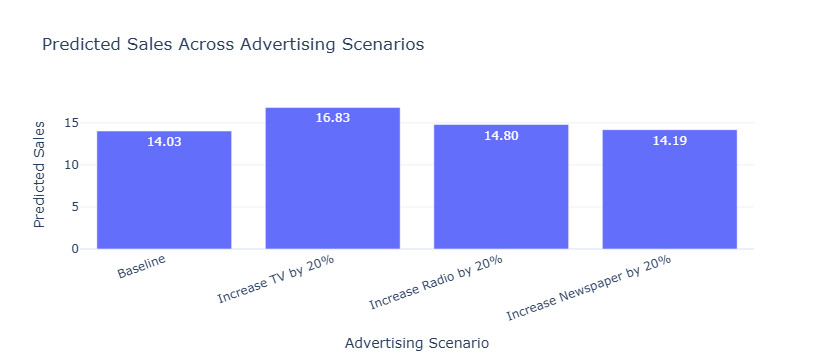

In [29]:
# ============================================================
# Compare Scenario Predictions
# ============================================================

fig = px.bar(
    scenario_comparison,
    x="Scenario",
    y="Predicted Sales",
    text_auto=".2f",
    hover_data=[
        "TV",
        "Radio",
        "Newspaper",
        "Total Budget",
        "Sales Change",
        "Sales Change (%)"
    ],
    title="Predicted Sales Across Advertising Scenarios",
    template="plotly_white"
)

fig.update_layout(
    xaxis_title="Advertising Scenario",
    yaxis_title="Predicted Sales",
    xaxis_tickangle=-20
)

fig.show()

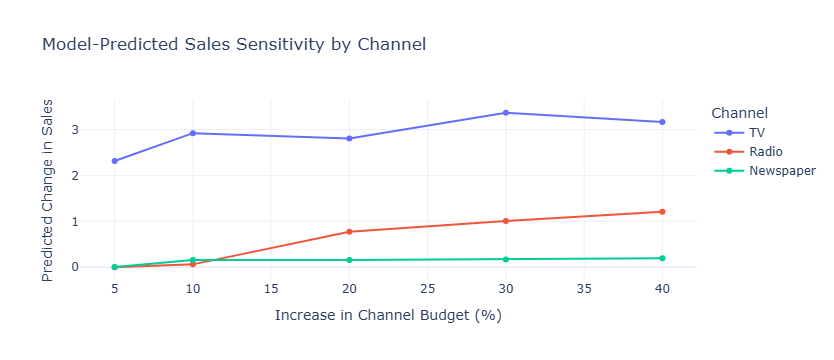

In [30]:
# ============================================================
# Channel Sensitivity Plot
# ============================================================

fig = px.line(
    sensitivity_analysis,
    x="Budget Increase (%)",
    y="Sales Change",
    color="Channel",
    markers=True,
    hover_data=[
        "Predicted Sales",
        "Sales Change (%)"
    ],
    title="Model-Predicted Sales Sensitivity by Channel",
    template="plotly_white"
)

fig.update_layout(
    xaxis_title="Increase in Channel Budget (%)",
    yaxis_title="Predicted Change in Sales"
)

fig.show()

In [31]:
# ============================================================
# Equal-Budget Reallocation Analysis
# ============================================================

baseline_total_budget = sum(
    baseline_scenario.values()
)

reallocation_amount = (
    baseline_total_budget
    * 0.10
)

reallocation_records = []

for source_channel in feature_columns:

    for destination_channel in feature_columns:

        if source_channel == destination_channel:
            continue

        scenario_budgets = (
            baseline_scenario.copy()
        )

        transferable_amount = min(
            reallocation_amount,
            scenario_budgets[
                source_channel
            ]
        )

        scenario_budgets[
            source_channel
        ] -= transferable_amount

        scenario_budgets[
            destination_channel
        ] += transferable_amount

        predicted_sales = predict_sales(
            tv_budget=scenario_budgets["TV"],
            radio_budget=scenario_budgets[
                "Radio"
            ],
            newspaper_budget=scenario_budgets[
                "Newspaper"
            ]
        )

        sales_change = (
            predicted_sales
            - baseline_prediction
        )

        reallocation_records.append({
            "Reallocation": (
                f"{source_channel} → "
                f"{destination_channel}"
            ),
            "Source Channel": source_channel,
            "Destination Channel": (
                destination_channel
            ),
            "Transferred Budget": (
                transferable_amount
            ),
            "TV": scenario_budgets["TV"],
            "Radio": scenario_budgets[
                "Radio"
            ],
            "Newspaper": scenario_budgets[
                "Newspaper"
            ],
            "Total Budget": sum(
                scenario_budgets.values()
            ),
            "Predicted Sales": (
                predicted_sales
            ),
            "Sales Change": sales_change,
            "Sales Change (%)": (
                sales_change
                / baseline_prediction
                * 100
            )
        })

reallocation_analysis = pd.DataFrame(
    reallocation_records
)

reallocation_analysis = (
    reallocation_analysis
    .sort_values(
        by="Predicted Sales",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    reallocation_analysis.style.format({
        "Transferred Budget": "{:.2f}",
        "TV": "{:.2f}",
        "Radio": "{:.2f}",
        "Newspaper": "{:.2f}",
        "Total Budget": "{:.2f}",
        "Predicted Sales": "{:.2f}",
        "Sales Change": "{:+.2f}",
        "Sales Change (%)": "{:+.2f}%"
    })
)

,Reallocation,Source Channel,Destination Channel,Transferred Budget,TV,Radio,Newspaper,Total Budget,Predicted Sales,Sales Change,Sales Change (%)
0,Newspaper → TV,Newspaper,TV,20.09,167.13,23.26,10.47,200.86,17.25,+3.22,+22.95%
1,Newspaper → Radio,Newspaper,Radio,20.09,147.04,43.35,10.47,200.86,16.41,+2.38,+16.96%
2,Radio → TV,Radio,TV,20.09,167.13,3.18,30.55,200.86,16.14,+2.11,+15.06%
3,TV → Radio,TV,Radio,20.09,126.96,43.35,30.55,200.86,15.75,+1.72,+12.26%
4,TV → Newspaper,TV,Newspaper,20.09,126.96,23.26,50.64,200.86,13.55,-0.48,-3.40%
5,Radio → Newspaper,Radio,Newspaper,20.09,147.04,3.18,50.64,200.86,11.77,-2.26,-16.10%


In [32]:
# ============================================================
# Validate Reallocation Budget Constraint
# ============================================================

assert np.allclose(
    reallocation_analysis[
        "Total Budget"
    ],
    baseline_total_budget
), (
    "One or more reallocation scenarios changed "
    "the total advertising budget."
)

print(
    "All reallocation scenarios preserve "
    "the baseline total budget."
)

All reallocation scenarios preserve the baseline total budget.


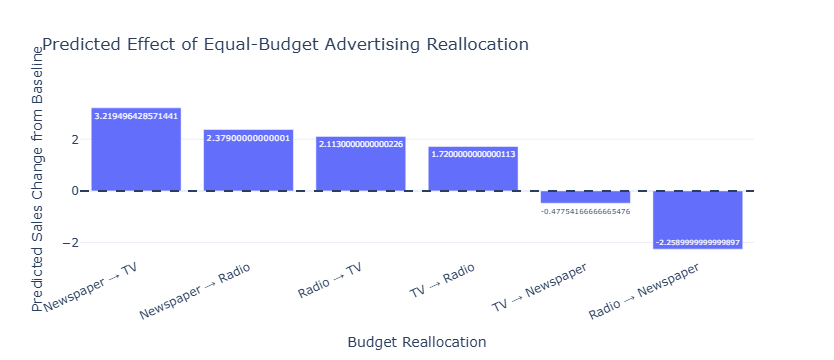

In [33]:
# ============================================================
# Reallocation Scenario Plot
# ============================================================

fig = px.bar(
    reallocation_analysis,
    x="Reallocation",
    y="Sales Change",
    text_auto="+.2f",
    hover_data=[
        "Transferred Budget",
        "Predicted Sales",
        "Sales Change (%)",
        "TV",
        "Radio",
        "Newspaper"
    ],
    title=(
        "Predicted Effect of Equal-Budget "
        "Advertising Reallocation"
    ),
    template="plotly_white"
)

fig.add_hline(
    y=0,
    line_dash="dash"
)

fig.update_layout(
    xaxis_title="Budget Reallocation",
    yaxis_title=(
        "Predicted Sales Change "
        "from Baseline"
    ),
    xaxis_tickangle=-25
)

fig.show()

In [34]:
# ============================================================
# Generate Evidence-Based Business Recommendations
# ============================================================

recommendations = []

strongest_correlation_channel = (
    channel_correlations
    .sort_values(
        by="Correlation with Sales",
        ascending=False
    )
    .iloc[0]["Channel"]
)

recommendations.append({
    "Priority": "High",
    "Recommendation": (
        f"Prioritize scenario testing for "
        f"{strongest_correlation_channel} advertising."
    ),
    "Evidence": (
        f"{strongest_correlation_channel} has the "
        "strongest observed linear relationship "
        "with sales in the historical dataset."
    ),
    "Caution": (
        "Correlation does not prove causation "
        "or financial return."
    )
})

if feature_strength_df is not None:

    strongest_model_channel = (
        feature_strength_df
        .sort_values(
            by="Model Strength",
            ascending=False
        )
        .iloc[0]["Feature"]
    )

    recommendations.append({
        "Priority": "High",
        "Recommendation": (
            f"Monitor {strongest_model_channel} "
            "closely in forecasting and planning."
        ),
        "Evidence": (
            f"The final model relies most heavily "
            f"on {strongest_model_channel} among "
            "the available predictors."
        ),
        "Caution": (
            "Model reliance does not establish "
            "business causality."
        )
    })

best_increase_scenario = (
    scenario_comparison[
        scenario_comparison[
            "Scenario"
        ] != "Baseline"
    ]
    .sort_values(
        by="Sales Change",
        ascending=False
    )
    .iloc[0]
)

recommendations.append({
    "Priority": "Medium",
    "Recommendation": (
        f"Test the '{best_increase_scenario['Scenario']}' "
        "scenario in a controlled campaign."
    ),
    "Evidence": (
        f"It produced the largest model-predicted "
        f"increase of "
        f"{best_increase_scenario['Sales Change']:.2f} "
        "sales units among the initial scenarios."
    ),
    "Caution": (
        "Validate the effect through a real-world "
        "experiment before scaling spend."
    )
})

best_reallocation = (
    reallocation_analysis.iloc[0]
)

recommendations.append({
    "Priority": "Medium",
    "Recommendation": (
        f"Evaluate reallocating budget from "
        f"{best_reallocation['Source Channel']} "
        f"to {best_reallocation['Destination Channel']}."
    ),
    "Evidence": (
        f"This fixed-budget scenario generated the "
        f"highest predicted sales of "
        f"{best_reallocation['Predicted Sales']:.2f}."
    ),
    "Caution": (
        "Use a limited pilot because the model "
        "does not include profit or campaign quality."
    )
})

weakest_correlation_channel = (
    channel_correlations
    .sort_values(
        by="Correlation with Sales",
        ascending=True
    )
    .iloc[0]["Channel"]
)

recommendations.append({
    "Priority": "Review",
    "Recommendation": (
        f"Review the strategic role of "
        f"{weakest_correlation_channel} advertising."
    ),
    "Evidence": (
        f"It has the weakest observed linear "
        "relationship with sales in this dataset."
    ),
    "Caution": (
        "The channel may still contribute through "
        "brand awareness or interactions not captured "
        "by the dataset."
    )
})

recommendations_df = pd.DataFrame(
    recommendations
)

display(recommendations_df)

,Priority,Recommendation,Evidence,Caution
0,High,Prioritize scenario testing for TV advertising.,TV has the strongest observed linear relations...,Correlation does not prove causation or financ...
1,High,Monitor TV closely in forecasting and planning.,The final model relies most heavily on TV amon...,Model reliance does not establish business cau...
2,Medium,Test the 'Increase TV by 20%' scenario in a co...,It produced the largest model-predicted increa...,Validate the effect through a real-world exper...
3,Medium,Evaluate reallocating budget from Newspaper to...,This fixed-budget scenario generated the highe...,Use a limited pilot because the model does not...
4,Review,Review the strategic role of Newspaper adverti...,It has the weakest observed linear relationshi...,The channel may still contribute through brand...


In [35]:
# ============================================================
# Define Historical Input Ranges
# ============================================================

input_ranges = {}

for feature in feature_columns:
    input_ranges[feature] = {
        "minimum": float(df[feature].min()),
        "maximum": float(df[feature].max()),
        "average": float(df[feature].mean()),
        "median": float(df[feature].median())
    }

input_ranges_df = pd.DataFrame([
    {
        "Feature": feature,
        "Minimum": values["minimum"],
        "Maximum": values["maximum"],
        "Average": values["average"],
        "Median": values["median"]
    }
    for feature, values in input_ranges.items()
])

display(
    input_ranges_df.style.format({
        "Minimum": "{:.2f}",
        "Maximum": "{:.2f}",
        "Average": "{:.2f}",
        "Median": "{:.2f}"
    })
)

,Feature,Minimum,Maximum,Average,Median
0,TV,0.70,296.40,147.04,149.75
1,Radio,0.00,49.60,23.26,22.90
2,Newspaper,0.30,114.00,30.55,25.75


In [36]:
# ============================================================
# Validate Advertising-Budget Inputs
# ============================================================

def validate_budget_inputs(
    tv_budget,
    radio_budget,
    newspaper_budget
):
    """
    Validate advertising-budget inputs.

    Returns
    -------
    list
        Warning messages for unusual or invalid inputs.
    """

    input_values = {
        "TV": float(tv_budget),
        "Radio": float(radio_budget),
        "Newspaper": float(newspaper_budget)
    }

    warnings_list = []

    for feature, value in input_values.items():

        if not np.isfinite(value):
            warnings_list.append(
                f"{feature} budget must be a finite number."
            )
            continue

        if value < 0:
            warnings_list.append(
                f"{feature} budget cannot be negative."
            )

        historical_minimum = input_ranges[
            feature
        ]["minimum"]

        historical_maximum = input_ranges[
            feature
        ]["maximum"]

        if value < historical_minimum:
            warnings_list.append(
                f"{feature} budget is below the historical "
                f"minimum of {historical_minimum:.2f}."
            )

        if value > historical_maximum:
            warnings_list.append(
                f"{feature} budget is above the historical "
                f"maximum of {historical_maximum:.2f}. "
                "The prediction may be less reliable."
            )

    return warnings_list

In [38]:
# ============================================================
# Test Input Validation
# ============================================================

validation_test = validate_budget_inputs(
    tv_budget=150.0,
    radio_budget=30.0,
    newspaper_budget=20.0
)

if validation_test:
    print("Warnings:")
    for warning_message in validation_test:
        print("-", warning_message)
else:
    print("Input validation passed with no warnings.")

Input validation passed with no warnings.


In [39]:
# ============================================================
# App-Ready Prediction Function
# ============================================================

def generate_prediction_summary(
    tv_budget,
    radio_budget,
    newspaper_budget,
    reference_prediction=None
):
    """
    Generate a structured prediction result for the app.
    """

    warnings_list = validate_budget_inputs(
        tv_budget=tv_budget,
        radio_budget=radio_budget,
        newspaper_budget=newspaper_budget
    )

    predicted_sales = predict_sales(
        tv_budget=tv_budget,
        radio_budget=radio_budget,
        newspaper_budget=newspaper_budget
    )

    total_budget = (
        float(tv_budget)
        + float(radio_budget)
        + float(newspaper_budget)
    )

    result = {
        "TV": float(tv_budget),
        "Radio": float(radio_budget),
        "Newspaper": float(newspaper_budget),
        "Total Budget": float(total_budget),
        "Predicted Sales": float(predicted_sales),
        "Warnings": warnings_list
    }

    if reference_prediction is not None:

        sales_change = (
            predicted_sales
            - reference_prediction
        )

        if reference_prediction != 0:
            sales_change_percent = (
                sales_change
                / reference_prediction
                * 100
            )
        else:
            sales_change_percent = np.nan

        result["Reference Prediction"] = float(
            reference_prediction
        )

        result["Sales Change"] = float(
            sales_change
        )

        result["Sales Change (%)"] = float(
            sales_change_percent
        )

    return result

In [40]:
# ============================================================
# Test App-Ready Prediction Output
# ============================================================

app_prediction_test = generate_prediction_summary(
    tv_budget=180.0,
    radio_budget=35.0,
    newspaper_budget=25.0,
    reference_prediction=baseline_prediction
)

display(
    pd.DataFrame([
        {
            key: value
            for key, value in app_prediction_test.items()
            if key != "Warnings"
        }
    ])
)

print("Warnings:", app_prediction_test["Warnings"])

,TV,Radio,Newspaper,Total Budget,Predicted Sales,Reference Prediction,Sales Change,Sales Change (%)
0,180.0,35.0,25.0,240.0,17.861417,14.027,3.834417,27.335971


Warnings: []


In [41]:
# ============================================================
# Create Streamlit Configuration
# ============================================================

streamlit_config = {
    "project_name": "AdIntel",
    "subtitle": (
        "Intelligent Sales Prediction "
        "& Advertising Analytics"
    ),
    "model_name": final_model_name,
    "feature_columns": feature_columns,
    "target_column": target_column,
    "input_ranges": input_ranges,
    "baseline_scenario": baseline_scenario,
    "baseline_prediction": float(
        baseline_prediction
    ),
    "model_metrics": {
        "cv_rmse": float(cv_mean_rmse),
        "test_r2": float(test_r2),
        "test_mae": float(test_mae),
        "test_rmse": float(test_rmse),
        "test_mape_percent": float(
            test_mape
        )
    },
    "disclaimer": (
        "Predictions are based on historical associations "
        "and should not be interpreted as guaranteed sales "
        "or advertising return on investment."
    )
}

display(
    pd.DataFrame({
        "Configuration": streamlit_config.keys(),
        "Value": [
            str(value)
            for value in streamlit_config.values()
        ]
    })
)

,Configuration,Value
0,project_name,AdIntel
1,subtitle,Intelligent Sales Prediction & Advertising Ana...
2,model_name,Random Forest
3,feature_columns,"['TV', 'Radio', 'Newspaper']"
4,target_column,Sales
5,input_ranges,"{'TV': {'minimum': 0.7, 'maximum': 296.4, 'ave..."
6,baseline_scenario,"{'TV': 147.0425, 'Radio': 23.264000000000006, ..."
7,baseline_prediction,14.026999999999992
8,model_metrics,"{'cv_rmse': 1.3015404052250497, 'test_r2': 0.9..."
9,disclaimer,Predictions are based on historical associatio...


In [42]:
# ============================================================
# Save Streamlit Configuration
# ============================================================

STREAMLIT_CONFIG_PATH = os.path.join(
    REPORT_DIR,
    "streamlit_config.json"
)

with open(
    STREAMLIT_CONFIG_PATH,
    "w",
    encoding="utf-8"
) as config_file:
    json.dump(
        streamlit_config,
        config_file,
        indent=4,
        default=str
    )

print(
    "Streamlit configuration saved at:",
    STREAMLIT_CONFIG_PATH
)

Streamlit configuration saved at: ../reports\streamlit_config.json


In [43]:
# ============================================================
# Save Scenario Analysis Reports
# ============================================================

SCENARIO_COMPARISON_PATH = os.path.join(
    REPORT_DIR,
    "scenario_comparison.csv"
)

SENSITIVITY_ANALYSIS_PATH = os.path.join(
    REPORT_DIR,
    "channel_sensitivity_analysis.csv"
)

REALLOCATION_ANALYSIS_PATH = os.path.join(
    REPORT_DIR,
    "budget_reallocation_analysis.csv"
)

scenario_comparison.to_csv(
    SCENARIO_COMPARISON_PATH,
    index=False
)

sensitivity_analysis.to_csv(
    SENSITIVITY_ANALYSIS_PATH,
    index=False
)

reallocation_analysis.to_csv(
    REALLOCATION_ANALYSIS_PATH,
    index=False
)

print("Scenario comparison saved.")
print("Sensitivity analysis saved.")
print("Budget reallocation analysis saved.")

Scenario comparison saved.
Sensitivity analysis saved.
Budget reallocation analysis saved.


In [44]:
# ============================================================
# Save Business Insight Reports
# ============================================================

CHANNEL_SUMMARY_PATH = os.path.join(
    REPORT_DIR,
    "channel_summary.csv"
)

CHANNEL_INSIGHTS_PATH = os.path.join(
    REPORT_DIR,
    "channel_insights.csv"
)

BUSINESS_RECOMMENDATIONS_PATH = os.path.join(
    REPORT_DIR,
    "business_recommendations.csv"
)

channel_summary.to_csv(
    CHANNEL_SUMMARY_PATH,
    index=False
)

channel_insights.to_csv(
    CHANNEL_INSIGHTS_PATH,
    index=False
)

recommendations_df.to_csv(
    BUSINESS_RECOMMENDATIONS_PATH,
    index=False
)

print("Channel summary saved.")
print("Channel insights saved.")
print("Business recommendations saved.")

Channel summary saved.
Channel insights saved.
Business recommendations saved.


In [45]:
# ============================================================
# Create App-Ready Business Summary
# ============================================================

best_scenario_record = (
    scenario_comparison[
        scenario_comparison["Scenario"] != "Baseline"
    ]
    .sort_values(
        by="Sales Change",
        ascending=False
    )
    .iloc[0]
)

best_reallocation_record = (
    reallocation_analysis
    .sort_values(
        by="Sales Change",
        ascending=False
    )
    .iloc[0]
)

business_summary = {
    "strongest_correlation_channel": (
        strongest_correlation_channel
    ),
    "weakest_correlation_channel": (
        weakest_correlation_channel
    ),
    "best_increase_scenario": {
        "scenario": best_scenario_record[
            "Scenario"
        ],
        "predicted_sales": float(
            best_scenario_record[
                "Predicted Sales"
            ]
        ),
        "sales_change": float(
            best_scenario_record[
                "Sales Change"
            ]
        ),
        "sales_change_percent": float(
            best_scenario_record[
                "Sales Change (%)"
            ]
        )
    },
    "best_reallocation_scenario": {
        "reallocation": best_reallocation_record[
            "Reallocation"
        ],
        "predicted_sales": float(
            best_reallocation_record[
                "Predicted Sales"
            ]
        ),
        "sales_change": float(
            best_reallocation_record[
                "Sales Change"
            ]
        ),
        "sales_change_percent": float(
            best_reallocation_record[
                "Sales Change (%)"
            ]
        )
    },
    "baseline_prediction": float(
        baseline_prediction
    ),
    "baseline_total_budget": float(
        baseline_total_budget
    )
}

if feature_strength_df is not None:
    business_summary[
        "strongest_model_channel"
    ] = strongest_model_channel

BUSINESS_SUMMARY_PATH = os.path.join(
    REPORT_DIR,
    "business_summary.json"
)

with open(
    BUSINESS_SUMMARY_PATH,
    "w",
    encoding="utf-8"
) as summary_file:
    json.dump(
        business_summary,
        summary_file,
        indent=4,
        default=str
    )

display(
    pd.DataFrame({
        "Business Summary Item": (
            business_summary.keys()
        ),
        "Value": [
            str(value)
            for value in business_summary.values()
        ]
    })
)

print(
    "Business summary saved at:",
    BUSINESS_SUMMARY_PATH
)

,Business Summary Item,Value
0,strongest_correlation_channel,TV
1,weakest_correlation_channel,Newspaper
2,best_increase_scenario,"{'scenario': 'Increase TV by 20%', 'predicted_..."
3,best_reallocation_scenario,"{'reallocation': 'Newspaper → TV', 'predicted_..."
4,baseline_prediction,14.026999999999992
5,baseline_total_budget,200.8605
6,strongest_model_channel,TV


Business summary saved at: ../reports\business_summary.json


In [46]:
# ============================================================
# Verify Notebook 6 Output Files
# ============================================================

expected_output_files = [
    STREAMLIT_CONFIG_PATH,
    SCENARIO_COMPARISON_PATH,
    SENSITIVITY_ANALYSIS_PATH,
    REALLOCATION_ANALYSIS_PATH,
    CHANNEL_SUMMARY_PATH,
    CHANNEL_INSIGHTS_PATH,
    BUSINESS_RECOMMENDATIONS_PATH,
    BUSINESS_SUMMARY_PATH
]

output_file_verification = pd.DataFrame({
    "File": [
        os.path.basename(path)
        for path in expected_output_files
    ],
    "Path": expected_output_files,
    "Saved": [
        os.path.exists(path)
        for path in expected_output_files
    ]
})

display(output_file_verification)

,File,Path,Saved
0,streamlit_config.json,../reports\streamlit_config.json,True
1,scenario_comparison.csv,../reports\scenario_comparison.csv,True
2,channel_sensitivity_analysis.csv,../reports\channel_sensitivity_analysis.csv,True
3,budget_reallocation_analysis.csv,../reports\budget_reallocation_analysis.csv,True
4,channel_summary.csv,../reports\channel_summary.csv,True
5,channel_insights.csv,../reports\channel_insights.csv,True
6,business_recommendations.csv,../reports\business_recommendations.csv,True
7,business_summary.json,../reports\business_summary.json,True


In [47]:
# ============================================================
# Validate Saved Output Files
# ============================================================

missing_output_files = [
    path
    for path in expected_output_files
    if not os.path.exists(path)
]

if missing_output_files:
    raise FileNotFoundError(
        "The following Notebook 6 output files "
        f"were not saved correctly: {missing_output_files}"
    )

print("All Notebook 6 output files were saved successfully.")

All Notebook 6 output files were saved successfully.


In [48]:
# ============================================================
# Reload and Validate Streamlit Configuration
# ============================================================

with open(
    STREAMLIT_CONFIG_PATH,
    "r",
    encoding="utf-8"
) as config_file:
    reloaded_streamlit_config = json.load(
        config_file
    )

required_config_keys = [
    "project_name",
    "subtitle",
    "model_name",
    "feature_columns",
    "target_column",
    "input_ranges",
    "baseline_scenario",
    "baseline_prediction",
    "model_metrics",
    "disclaimer"
]

missing_config_keys = [
    key
    for key in required_config_keys
    if key not in reloaded_streamlit_config
]

if missing_config_keys:
    raise KeyError(
        "The Streamlit configuration is missing: "
        f"{missing_config_keys}"
    )

print("Streamlit configuration reloaded successfully.")

display(
    pd.DataFrame({
        "Configuration": (
            reloaded_streamlit_config.keys()
        ),
        "Value": [
            str(value)
            for value in (
                reloaded_streamlit_config.values()
            )
        ]
    })
)

Streamlit configuration reloaded successfully.


,Configuration,Value
0,project_name,AdIntel
1,subtitle,Intelligent Sales Prediction & Advertising Ana...
2,model_name,Random Forest
3,feature_columns,"['TV', 'Radio', 'Newspaper']"
4,target_column,Sales
5,input_ranges,"{'TV': {'minimum': 0.7, 'maximum': 296.4, 'ave..."
6,baseline_scenario,"{'TV': 147.0425, 'Radio': 23.264000000000006, ..."
7,baseline_prediction,14.026999999999992
8,model_metrics,"{'cv_rmse': 1.3015404052250497, 'test_r2': 0.9..."
9,disclaimer,Predictions are based on historical associatio...


In [49]:
# ============================================================
# Reload and Validate Business Summary
# ============================================================

with open(
    BUSINESS_SUMMARY_PATH,
    "r",
    encoding="utf-8"
) as summary_file:
    reloaded_business_summary = json.load(
        summary_file
    )

required_summary_keys = [
    "strongest_correlation_channel",
    "weakest_correlation_channel",
    "best_increase_scenario",
    "best_reallocation_scenario",
    "baseline_prediction",
    "baseline_total_budget"
]

missing_summary_keys = [
    key
    for key in required_summary_keys
    if key not in reloaded_business_summary
]

if missing_summary_keys:
    raise KeyError(
        "The business summary is missing: "
        f"{missing_summary_keys}"
    )

print("Business summary reloaded successfully.")

display(
    pd.DataFrame({
        "Summary Item": (
            reloaded_business_summary.keys()
        ),
        "Value": [
            str(value)
            for value in (
                reloaded_business_summary.values()
            )
        ]
    })
)

Business summary reloaded successfully.


,Summary Item,Value
0,strongest_correlation_channel,TV
1,weakest_correlation_channel,Newspaper
2,best_increase_scenario,"{'scenario': 'Increase TV by 20%', 'predicted_..."
3,best_reallocation_scenario,"{'reallocation': 'Newspaper → TV', 'predicted_..."
4,baseline_prediction,14.026999999999992
5,baseline_total_budget,200.8605
6,strongest_model_channel,TV


In [50]:
# ============================================================
# Test Complete Streamlit Prediction Workflow
# ============================================================

app_test_input = {
    feature: float(
        reloaded_streamlit_config[
            "baseline_scenario"
        ][feature]
    )
    for feature in feature_columns
}

app_test_result = generate_prediction_summary(
    tv_budget=app_test_input["TV"],
    radio_budget=app_test_input["Radio"],
    newspaper_budget=app_test_input[
        "Newspaper"
    ],
    reference_prediction=float(
        reloaded_streamlit_config[
            "baseline_prediction"
        ]
    )
)

app_test_dataframe = pd.DataFrame([
    {
        key: value
        for key, value in app_test_result.items()
        if key != "Warnings"
    }
])

display(
    app_test_dataframe.style.format({
        "TV": "{:.2f}",
        "Radio": "{:.2f}",
        "Newspaper": "{:.2f}",
        "Total Budget": "{:.2f}",
        "Predicted Sales": "{:.2f}",
        "Reference Prediction": "{:.2f}",
        "Sales Change": "{:+.2f}",
        "Sales Change (%)": "{:+.2f}%"
    })
)

print("Warnings:", app_test_result["Warnings"])

,TV,Radio,Newspaper,Total Budget,Predicted Sales,Reference Prediction,Sales Change,Sales Change (%)
0,147.04,23.26,30.55,200.86,14.03,14.03,+0.00,+0.00%


Warnings: []


In [51]:
# ============================================================
# Validate Complete App Workflow
# ============================================================

assert np.isfinite(
    app_test_result["Predicted Sales"]
), (
    "The app workflow generated an invalid prediction."
)

assert app_test_result["Total Budget"] >= 0, (
    "The app workflow generated an invalid total budget."
)

assert set(feature_columns).issubset(
    app_test_result.keys()
), (
    "The app result does not contain all required features."
)

assert abs(
    app_test_result["Predicted Sales"]
    - baseline_prediction
) < 1e-8, (
    "The app baseline prediction does not match "
    "the notebook baseline prediction."
)

print(
    "The complete Streamlit prediction workflow "
    "passed all validation checks."
)

The complete Streamlit prediction workflow passed all validation checks.


In [52]:
# ============================================================
# Final Notebook 6 Summary
# ============================================================

notebook_6_summary = pd.DataFrame({
    "Item": [
        "Final model loaded",
        "Model metadata loaded",
        "Prediction workflow validated",
        "Business KPI summary created",
        "Channel analysis completed",
        "Feature interpretation prepared",
        "What-if analysis completed",
        "Sensitivity analysis completed",
        "Fixed-budget reallocation completed",
        "Business recommendations generated",
        "Input validation created",
        "Streamlit configuration saved",
        "Business reports saved",
        "Business summary saved",
        "Saved assets reloaded",
        "App workflow validated",
        "Ready for Streamlit app"
    ],
    "Status": [
        "Completed"
    ] * 17
})

display(notebook_6_summary)

,Item,Status
0,Final model loaded,Completed
1,Model metadata loaded,Completed
2,Prediction workflow validated,Completed
3,Business KPI summary created,Completed
4,Channel analysis completed,Completed
5,Feature interpretation prepared,Completed
6,What-if analysis completed,Completed
7,Sensitivity analysis completed,Completed
8,Fixed-budget reallocation completed,Completed
9,Business recommendations generated,Completed
